<a href="https://colab.research.google.com/github/choihj-01/Hybrid-Model-Attention/blob/main/Panasonic_CNN_LSTM_Attention_0405.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Panasonic 18650PF SOC Estimation using CNN-LSTM-Attention
## Based on LG battery baseline code, adapted for Panasonic dataset

**Data**: Panasonic 18650PF Li-ion battery (2.9Ah)  
**Temperatures**: -20°C, -10°C, 0°C, 10°C, 25°C  
**Features**: Voltage, Current, Temperature → Normalized + Moving Average  
**Model**: CNN-LSTM with Self-Attention

In [1]:
# Cell 0: Install dependencies & imports
!pip install keras-self-attention

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, ReLU
from tensorflow.keras.layers import Flatten, LSTM, Bidirectional
from tensorflow.keras.layers import TimeDistributed, Conv1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras_self_attention import SeqSelfAttention
import time
import pickle
import os
import json

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18895 sha256=325445a89d164c95b1569441ad970ccdd8a1ac8bbf6e42285dd2e5745b288ae2
  Stored in directory: /root/.cache/pip/wheels/9a/9d/6e/09a0f61c2edeaea9f96fecdc67f31455c363bb44a4ddabe746
Successfully built keras-self-attention


In [2]:
# Cell 1: Google Drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cell 2: Configuration
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# === Path to Panasonic data ===
# Upload Panasonic_data.pkl to your Google Drive and set the path here
DATA_PATH = '/content/drive/MyDrive/Panasonic_soc/Panasonic_data.pkl'
SAVE_DIR = '/content/drive/MyDrive/Panasonic_models/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Temperature directories available in Panasonic dataset
temperature_dirs = ['-20degC', '-10degC', '0degC', '10degC', '25degC']

Num GPUs Available: 1


In [4]:
# Cell 3: Load Panasonic data from pickle
with open(DATA_PATH, 'rb') as f:
    panasonic_data = pickle.load(f)

# Verify data structure
for temp in sorted(panasonic_data.keys()):
    cycles = sorted(panasonic_data[temp].keys())
    print(f'{temp}: {cycles}')

-10degC: ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN', 'UDDS', 'US06', 'US06_HWFET_UDDS_LA92']
-20degC: ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'HWFET_UDDS_LA92_NN', 'LA92', 'NN', 'UDDS', 'US06']
0degC: ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN', 'UDDS', 'US06']
10degC: ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN', 'UDDS', 'US06', 'US06_HWFET_UDDS_LA92_NN']
25degC: ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFTa', 'HWFTb', 'LA92', 'NN', 'UDDS', 'US06']


In [5]:
# Cell 4: Define helper functions (same logic as original baseline)

def timeorder(cycles_order):
    """Concatenate multiple cycles with continuous time adjustment."""
    x_length = cycles_order[0][0].shape[1]  # number of x features
    y_length = cycles_order[0][1].shape[1]  # number of y features
    x = np.zeros((0, x_length), float)
    y = np.zeros((0, y_length), float)
    prev_cycle_x = np.zeros((100, x_length), float)
    prev_cycle_y = np.zeros((100, y_length), float)
    for cycle_order in cycles_order:
        next_cycle_x = np.array(cycle_order[0])
        next_cycle_y = np.array(cycle_order[1])
        # Adjust time to be continuous
        next_cycle_x[:, 0] = next_cycle_x[:, 0] - (next_cycle_x[:, 0][0] - prev_cycle_x[:, 0][-1])
        next_cycle_y[:, 0] = next_cycle_y[:, 0] - (next_cycle_y[:, 0][0] - prev_cycle_y[:, 0][-1])
        prev_cycle_x = next_cycle_x
        prev_cycle_y = next_cycle_y
        x = np.concatenate((x, next_cycle_x))
        y = np.concatenate((y, next_cycle_y))
    return x, y


def average(xtraingroup, steps):
    """Compute moving average of V and I over 'steps' window."""
    V = pd.Series(xtraingroup[:, 0]).rolling(window=steps).mean().dropna().values
    I = pd.Series(xtraingroup[:, 1]).rolling(window=steps).mean().dropna().values
    return V, I


def get_panasonic_data(pkl_data, temp_list, cycle_names_per_temp):
    """
    Load cycles from Panasonic pickle data.
    pkl_data: loaded pickle dict
    temp_list: list of temperature keys (e.g., ['-20degC', '-10degC', ...])
    cycle_names_per_temp: list of lists, cycle names for each temperature
    Returns: list of (x, y) tuples, same format as original get_data_up
             x = [Time, Voltage, Current, Temperature]
             y = [Time, SOC]
    """
    cycles = []
    for i, temp in enumerate(temp_list):
        for cycle_name in cycle_names_per_temp[i]:
            if cycle_name not in pkl_data[temp]:
                print(f'WARNING: {temp}/{cycle_name} not found, skipping.')
                continue
            d = pkl_data[temp][cycle_name]
            n = len(d['voltage'])
            # Create time array: 0.1s per sample
            time_arr = np.arange(n) * 0.1
            voltage = d['voltage'].astype(float)
            current = d['current'].astype(float)
            temperature = d['temperature'].astype(float)
            soc = d['soc'].astype(float)

            x = np.column_stack([time_arr, voltage, current, temperature])
            y = np.column_stack([time_arr, soc])
            cycles.append((x, y))
    return cycles


def get_panasonic_single(pkl_data, temp, cycle_name):
    """Load a single cycle for per-file testing."""
    d = pkl_data[temp][cycle_name]
    n = len(d['voltage'])
    time_arr = np.arange(n) * 0.1
    voltage = d['voltage'].astype(float)
    current = d['current'].astype(float)
    temperature = d['temperature'].astype(float)
    soc = d['soc'].astype(float)

    x = np.column_stack([time_arr, voltage, current, temperature])
    y = np.column_stack([time_arr, soc])
    return [(x, y)]

In [6]:
# Cell 5: Define train/test split for each temperature
# Panasonic dataset: standard drive cycles for train, remaining for test
#
# Available cycles per temperature:
# -20degC: Cycle_1-4, HWFET, HWFET_UDDS_LA92_NN, LA92, NN, UDDS, US06
# -10degC: Cycle_1-4, HWFET, LA92, NN, UDDS, US06, US06_HWFET_UDDS_LA92
#   0degC: Cycle_1-4, HWFET, LA92, NN, UDDS, US06
#  10degC: Cycle_1-4, HWFET, LA92, NN, UDDS, US06, US06_HWFET_UDDS_LA92_NN
#  25degC: Cycle_1-4, HWFTa, HWFTb, LA92, NN, UDDS, US06

# Train: Cycle_1-4 + a few standard cycles
# Test: remaining standard drive cycles

train_names_n20 = ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN']
test_names_n20  = ['UDDS', 'US06']

train_names_n10 = ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN']
test_names_n10  = ['UDDS', 'US06']

train_names_0   = ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN']
test_names_0    = ['UDDS', 'US06']

train_names_10  = ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN']
test_names_10   = ['UDDS', 'US06']

train_names_25  = ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFTa', 'LA92', 'NN']
test_names_25   = ['UDDS', 'US06']

train_names_all = [train_names_n20, train_names_n10, train_names_0, train_names_10, train_names_25]
test_names_all  = [test_names_n20,  test_names_n10,  test_names_0,  test_names_10,  test_names_25]

# Test file pairs for per-file evaluation
test_file_pairs = [
    ('-20degC', 'UDDS'),    ('-20degC', 'US06'),
    ('-10degC', 'UDDS'),    ('-10degC', 'US06'),
    ('0degC',   'UDDS'),    ('0degC',   'US06'),
    ('10degC',  'UDDS'),    ('10degC',  'US06'),
    ('25degC',  'UDDS'),    ('25degC',  'US06'),
]

In [7]:
# Cell 6: Load and preprocess data (same pipeline as original)

# Load train and test cycles
cycles_train = get_panasonic_data(panasonic_data, temperature_dirs, train_names_all)
x_train_order, y_train_order = timeorder(cycles_train)

cycles_test = get_panasonic_data(panasonic_data, temperature_dirs, test_names_all)
x_test_order, y_test_order = timeorder(cycles_test)

print(f'Train samples: {len(x_train_order)}, Test samples: {len(x_test_order)}')

# Create DataFrames
df_xtrain = pd.DataFrame(x_train_order, columns=['t', 'V', 'I', 'T'])
df_ytrain = pd.DataFrame(y_train_order, columns=['t', 'SOC'])

df_xtest = pd.DataFrame(x_test_order, columns=['t', 'V', 'I', 'T'])
df_ytest = pd.DataFrame(y_test_order, columns=['t', 'SOC'])

# Min-max normalize V, I, T using TRAIN statistics
cols_to_norm = ['V', 'I', 'T']
cols_to_norm_new = ['V_norm', 'I_norm', 'T_norm']

# Compute train min/max first
train_stats = {}
for col in cols_to_norm:
    train_stats[col] = (df_xtrain[col].min(), df_xtrain[col].max())
print('Train stats:', train_stats)

# Normalize train using train stats
for col, col_new in zip(cols_to_norm, cols_to_norm_new):
    vmin, vmax = train_stats[col]
    df_xtrain[col_new] = (df_xtrain[col] - vmin) / (vmax - vmin)

# Normalize test using TRAIN stats (critical for correct evaluation)
for col, col_new in zip(cols_to_norm, cols_to_norm_new):
    vmin, vmax = train_stats[col]
    df_xtest[col_new] = (df_xtest[col] - vmin) / (vmax - vmin)

# Group by time and compute mean (handles any duplicate timestamps)
df_xtrain_reset = df_xtrain.groupby(['t']).mean().reset_index()
df_xtrain_group = df_xtrain.groupby(['t']).mean()
df_ytrain_reset = df_ytrain.groupby(['t']).mean().reset_index()

df_xtest_reset = df_xtest.groupby(['t']).mean().reset_index()
df_xtest_group = df_xtest.groupby(['t']).mean()
df_ytest_reset = df_ytest.groupby(['t']).mean().reset_index()

# Save train minmax for per-file test evaluation later
train_minmax = {
    'V': (df_xtrain_reset['V'].min(), df_xtrain_reset['V'].max()),
    'I': (df_xtrain_reset['I'].min(), df_xtrain_reset['I'].max()),
    'T': (df_xtrain_reset['T'].min(), df_xtrain_reset['T'].max()),
}

# Compute moving averages on normalized V, I
xtrain_group = np.array(df_xtrain_group[['V_norm', 'I_norm']])
xtest_group = np.array(df_xtest_group[['V_norm', 'I_norm']])

k = 400  # Moving average window size (same as original)

V_avg, I_avg = average(xtrain_group, k)
V_avg_test, I_avg_test = average(xtest_group, k)

df_V_avg = pd.DataFrame(V_avg, columns=['V_avg'])
df_I_avg = pd.DataFrame(I_avg, columns=['I_avg'])
df_V_avg_test = pd.DataFrame(V_avg_test, columns=['V_avg'])
df_I_avg_test = pd.DataFrame(I_avg_test, columns=['I_avg'])

# Concatenate and shift averages
df_tot = pd.concat([df_xtrain_reset, df_V_avg, df_I_avg], axis=1)
df_tot_test = pd.concat([df_xtest_reset, df_V_avg_test, df_I_avg_test], axis=1)

df_tot['V_avg'] = df_tot.V_avg.shift(periods=k)
df_tot['I_avg'] = df_tot.I_avg.shift(periods=k)
df_tot.loc[:k, 'V_avg'] = df_tot['V_avg'].iloc[k+1] if len(df_tot) > k+1 else 0
df_tot.loc[:k, 'I_avg'] = df_tot['I_avg'].iloc[k+1] if len(df_tot) > k+1 else 0

df_tot_test['V_avg'] = df_tot_test.V_avg.shift(periods=k)
df_tot_test['I_avg'] = df_tot_test.I_avg.shift(periods=k)
df_tot_test.loc[:k, 'V_avg'] = df_tot_test['V_avg'].iloc[k+1] if len(df_tot_test) > k+1 else 0
df_tot_test.loc[:k, 'I_avg'] = df_tot_test['I_avg'].iloc[k+1] if len(df_tot_test) > k+1 else 0

# Final feature/target arrays
dftrain_x = df_tot[['V_norm', 'I_norm', 'T_norm', 'V_avg', 'I_avg']]
dftest_x = df_tot_test[['V_norm', 'I_norm', 'T_norm', 'V_avg', 'I_avg']]
dftrain_y = df_ytrain_reset['SOC']
dftest_y = df_ytest_reset['SOC']

train_X = dftrain_x.to_numpy()
test_X = dftest_x.to_numpy()
train_y = dftrain_y.to_numpy()
test_y = dftest_y.to_numpy()

# Reshape for CNN-LSTM: (samples, n_seq, n_features, n_steps)
n_features = 5
n_seq = 1
n_steps = 1

train_X = train_X.reshape((train_X.shape[0], n_seq, n_features, n_steps))
test_X = test_X.reshape((test_X.shape[0], n_seq, n_features, n_steps))
train_y = train_y.reshape((train_y.shape[0]))
test_y = test_y.reshape((test_y.shape[0]))

print(f'train_X: {train_X.shape}, train_y: {train_y.shape}')
print(f'test_X:  {test_X.shape},  test_y:  {test_y.shape}')

Train samples: 2729000, Test samples: 946743
Train stats: {'V': (2.28588, 4.32296), 'I': (-21.06144, 10.70564), 'T': (-20.5260952, 30.02432)}
train_X: (2728966, 1, 5, 1), train_y: (2728966,)
test_X:  (946734, 1, 5, 1),  test_y:  (946734,)


In [8]:
# Cell 7: Build per-file test function (uses train_minmax for normalization)

def build_test_xy_for_one_file(pkl_data, temp, cycle_name, train_minmax, k=400):
    """
    Build test X, y for a single cycle file, using train normalization stats.
    Same logic as original build_test_xy_for_one_file.
    """
    # 1) Load single cycle
    cycles = get_panasonic_single(pkl_data, temp, cycle_name)
    x_order, y_order = timeorder(cycles)

    # 2) DataFrame
    df_x = pd.DataFrame(x_order, columns=['t', 'V', 'I', 'T'])
    df_y = pd.DataFrame(y_order, columns=['t', 'SOC'])

    # 3) Group by time
    df_x_reset = df_x.groupby(['t']).mean().reset_index()
    df_y_reset = df_y.groupby(['t']).mean().reset_index()

    # 4) Normalize using TRAIN min/max
    Vmin, Vmax = train_minmax['V']
    Imin, Imax = train_minmax['I']
    Tmin, Tmax = train_minmax['T']

    df_x_reset['V_norm'] = (df_x_reset['V'] - Vmin) / (Vmax - Vmin)
    df_x_reset['I_norm'] = (df_x_reset['I'] - Imin) / (Imax - Imin)
    df_x_reset['T_norm'] = (df_x_reset['T'] - Tmin) / (Tmax - Tmin)

    # 5) Moving average on normalized V, I
    x_group_norm = np.array(df_x_reset[['V_norm', 'I_norm']])
    V_avg, I_avg = average(x_group_norm, k)

    df_V_avg = pd.DataFrame(V_avg, columns=['V_avg'])
    df_I_avg = pd.DataFrame(I_avg, columns=['I_avg'])

    df_tot_test = pd.concat([df_x_reset, df_V_avg, df_I_avg], axis=1)

    df_tot_test['V_avg'] = df_tot_test['V_avg'].shift(periods=k)
    df_tot_test['I_avg'] = df_tot_test['I_avg'].shift(periods=k)
    df_tot_test.loc[:k, 'V_avg'] = df_tot_test['V_avg'].iloc[k+1] if len(df_tot_test) > k+1 else 0
    df_tot_test.loc[:k, 'I_avg'] = df_tot_test['I_avg'].iloc[k+1] if len(df_tot_test) > k+1 else 0

    # 6) Final arrays
    dftest_x = df_tot_test[['V_norm', 'I_norm', 'T_norm', 'V_avg', 'I_avg']]
    dftest_y = df_y_reset['SOC']

    test_X = dftest_x.to_numpy()
    test_y = dftest_y.to_numpy().reshape(-1)

    # 7) Reshape: (N, 1, 5, 1)
    test_X = test_X.reshape((test_X.shape[0], n_seq, n_features, n_steps))

    return test_X, test_y

In [9]:
# Cell 8: Model architecture definitions
# Architecture 1: 2xCNN + 3xLSTM + Attention (same as original create_Cnn_lstm)

def create_Cnn_lstm(optimizations, latent_dimension, loss_function, conv_dimension):
    unit1 = latent_dimension[0]
    unit2 = latent_dimension[1]
    unit3 = latent_dimension[2]
    cnn1 = conv_dimension[0]
    cnn2 = conv_dimension[1]
    model = Sequential()
    model.add(TimeDistributed(Conv1D(filters=cnn1, kernel_size=3, kernel_initializer='he_uniform',
                                     activation='relu'), input_shape=(None, n_features, n_steps)))
    model.add(TimeDistributed(Conv1D(filters=cnn2, kernel_size=3, kernel_initializer='he_uniform',
                                     activation='relu')))
    model.add(TimeDistributed(Flatten()))
    model.add(LSTM(unit1, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                   return_sequences=True))
    model.add(SeqSelfAttention(attention_activation='relu'))
    model.add(LSTM(unit2, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                   return_sequences=True))
    model.add(SeqSelfAttention(attention_activation='relu'))
    model.add(LSTM(unit3, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                   return_sequences=False))
    model.add(Dense(1))
    model.add(LeakyReLU(alpha=10e-9))
    print("Params:", model.count_params())
    model.compile(optimizer=optimizations, loss=loss_function)
    return model


# Architecture 2: 1xCNN + 3xBidirectional LSTM + Attention
def create_Cnn1_Bilstm3(optimizations, latent_dimension, loss_function, conv_dimension):
    unit1 = latent_dimension[0]
    unit2 = latent_dimension[1]
    unit3 = latent_dimension[2]
    cnn = conv_dimension
    model = Sequential()
    model.add(TimeDistributed(Conv1D(filters=cnn, kernel_size=3, kernel_initializer='he_uniform',
                                     activation='relu'), input_shape=(None, n_features, n_steps)))
    model.add(TimeDistributed(Flatten()))
    model.add(Bidirectional(LSTM(unit1, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                                 return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation='relu'))
    model.add(Bidirectional(LSTM(unit2, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                                 return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation='relu'))
    model.add(Bidirectional(LSTM(unit3, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                                 return_sequences=False)))
    model.add(Dense(1))
    model.add(LeakyReLU(alpha=10e-9))
    print("Params:", model.count_params())
    model.compile(optimizer=optimizations, loss=loss_function)
    return model


# Architecture 3: 2xCNN + 3xBidirectional LSTM + Attention
def create_Cnn2_Bilstm3(optimizations, latent_dimension, loss_function, conv_dimension):
    unit1 = latent_dimension[0]
    unit2 = latent_dimension[1]
    unit3 = latent_dimension[2]
    cnn1 = conv_dimension[0]
    cnn2 = conv_dimension[1]
    model = Sequential()
    model.add(TimeDistributed(Conv1D(filters=cnn1, kernel_size=3, kernel_initializer='he_uniform',
                                     activation='relu'), input_shape=(None, n_features, n_steps)))
    model.add(TimeDistributed(Conv1D(filters=cnn2, kernel_size=3, kernel_initializer='he_uniform',
                                     activation='relu')))
    model.add(TimeDistributed(Flatten()))
    model.add(Bidirectional(LSTM(unit1, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                                 return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation='relu'))
    model.add(Bidirectional(LSTM(unit2, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                                 return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation='relu'))
    model.add(Bidirectional(LSTM(unit3, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                                 return_sequences=False)))
    model.add(Dense(1))
    model.add(LeakyReLU(alpha=10e-9))
    print("Params:", model.count_params())
    model.compile(optimizer=optimizations, loss=loss_function)
    return model


# Architecture 4: 1xCNN + 2xBidirectional LSTM + Attention
def create_Cnn1_Bilstm2(optimizations, latent_dimension, loss_function, conv_dimension):
    unit1 = latent_dimension[0]
    unit2 = latent_dimension[1]
    cnn1 = conv_dimension
    model = Sequential()
    model.add(TimeDistributed(Conv1D(filters=cnn1, kernel_size=3, kernel_initializer='he_uniform',
                                     activation='relu'), input_shape=(None, n_features, n_steps)))
    model.add(TimeDistributed(Flatten()))
    model.add(Bidirectional(LSTM(unit1, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                                 return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation='relu'))
    model.add(Bidirectional(LSTM(unit2, activation='relu', kernel_initializer=tf.keras.initializers.he_normal,
                                 return_sequences=False)))
    model.add(Dense(1))
    model.add(LeakyReLU(alpha=10e-9))
    print("Params:", model.count_params())
    model.compile(optimizer=optimizations, loss=loss_function)
    return model

In [10]:
# Cell 9: Training & evaluation function

def Optimize(model_fn, opts, dim, loss, conv, batch, model_name,
             epoch=515, verbose=0):
    """
    Train a model and evaluate on test set.
    model_fn: one of the create_* functions
    model_name: string for saving (e.g., 'CNN_LSTM_att')
    """
    model_generated = f" batch: {batch} | dim: {dim} | loss: {loss} | epoch: {epoch}"
    model = model_fn(opts, dim, loss, conv)
    t0 = time.time()
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True
    )
    history_temp = model.fit(train_X, train_y, epochs=epoch, batch_size=batch,
                             validation_data=(test_X, test_y), verbose=verbose,
                             callbacks=[early_stop])

    # Save model
    save_path = os.path.join(SAVE_DIR, f'model_{model_name}.keras')
    model.save(save_path)
    print(f'Model saved to {save_path}')

    training_time = time.time() - t0
    print(f"Training time: {training_time:.1f}s")

    # Predict on combined test set
    y_predict = model.predict(test_X, verbose=0).reshape(-1)
    rmse_temp = np.sqrt(mean_squared_error(test_y, y_predict))
    MAE = mean_absolute_error(test_y, y_predict)

    final_loss = history_temp.history['loss'][-1]
    final_val_loss = history_temp.history['val_loss'][-1]

    print(f'RMSE: {rmse_temp:.6f}, MAE: {MAE:.6f}')
    print(f'Final loss: {final_loss:.6f}, val_loss: {final_val_loss:.6f}')
    print(model_generated)

    # Plot training history
    fig = plt.figure(figsize=(10, 4))
    plt.plot(history_temp.history['loss'], label='train')
    plt.plot(history_temp.history['val_loss'], label='validation')
    plt.title('Model Loss')
    plt.yscale('log')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.annotate(f"RMSE={rmse_temp:.5f}, MAE={MAE:.5f}, time={training_time/60:.1f}min",
                 (100, 0.01))
    plt.tight_layout()
    plt.show()

    # Plot true vs predicted on combined test set
    plt.figure(figsize=(12, 4))
    plt.plot(test_y, label='True (test)')
    plt.plot(y_predict, label='Predicted')
    plt.xlabel('Time step')
    plt.ylabel('SoC')
    plt.title('Test Data: True vs Predicted (All temperatures combined)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        'model_name': model_name,
        'rmse': rmse_temp,
        'mae': MAE,
        'loss': final_loss,
        'val_loss': final_val_loss,
        'batch': batch,
        'dim': str(dim),
        'conv': str(conv),
        'time_min': training_time / 60.0
    }

In [11]:
# Cell 10: Per-file evaluation function

def evaluate_per_file(model, model_name):
    """Evaluate model on each test file individually and plot best results."""
    per_file_results = []
    for temp, cycle_name in test_file_pairs:
        one_test_X, one_test_y = build_test_xy_for_one_file(
            panasonic_data, temp, cycle_name, train_minmax, k=400
        )
        one_pred = model.predict(one_test_X, verbose=0).reshape(-1)
        rmse = np.sqrt(mean_squared_error(one_test_y, one_pred))
        mae = mean_absolute_error(one_test_y, one_pred)
        per_file_results.append((f'{temp}/{cycle_name}', rmse, mae, one_test_y, one_pred))

    # Sort by RMSE
    per_file_results.sort(key=lambda x: (x[1], x[2]))
    print(f'\n===== Per-file results for {model_name} =====')
    for r in per_file_results:
        print(f'{r[0]:30s} | RMSE={r[1]:.6f} | MAE={r[2]:.6f}')

    print(f'\n[Top-2 Best Test Files by RMSE]')
    for r in per_file_results[:2]:
        print(f'{r[0]} | RMSE={r[1]:.6f} | MAE={r[2]:.6f}')

    # Plot best 2 and worst 1
    for r in per_file_results[:2]:
        plt.figure(figsize=(10, 3))
        plt.plot(r[3], label='True')
        plt.plot(r[4], label='Predicted')
        plt.xlabel('Time step')
        plt.ylabel('SoC')
        plt.title(f'{model_name} - {r[0]} (RMSE={r[1]:.5f})')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Plot worst case
    worst = per_file_results[-1]
    plt.figure(figsize=(10, 3))
    plt.plot(worst[3], label='True')
    plt.plot(worst[4], label='Predicted')
    plt.xlabel('Time step')
    plt.ylabel('SoC')
    plt.title(f'{model_name} - {worst[0]} (WORST, RMSE={worst[1]:.5f})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return per_file_results

---
## Training: Architecture 1 - 2xCNN + 3xLSTM + Attention
This is the main architecture from the original baseline.

In [ ]:
# Cell 11: Train Architecture 1 (2xCNN + 3xLSTM + Attention) - Grid Search
latent_dimension = [[110, 90, 70]]
conv_dimension = [[8, 8]]
loss_function = ['mse']
learning_rates = [1e-4]
batch_sizes = [256]

results_arch1 = []
run_id = 0

for conv in conv_dimension:
    for lr in learning_rates:
        for dim in latent_dimension:
            for loss in loss_function:
                for batch in batch_sizes:
                    run_id += 1
                    print(f'\n=== Run {run_id} | conv={conv} dim={dim} lr={lr} batch={batch} ===')
                    opts = Adam(learning_rate=lr)
                    result = Optimize(
                        model_fn=create_Cnn_lstm,
                        opts=opts, dim=dim, loss=loss, conv=conv,
                        batch=batch, model_name='Panasonic_CNN2_LSTM3_att'
                    )
                    results_arch1.append(result)

if results_arch1:
    df_results = pd.DataFrame(results_arch1).sort_values('rmse')
    print('\n=== Architecture 1 Results ===')
    print(df_results[['model_name', 'rmse', 'mae', 'batch', 'dim', 'conv']].to_string())

In [ ]:
# Cell 12: Per-file evaluation for Architecture 1
model_arch1 = load_model(
    os.path.join(SAVE_DIR, 'model_Panasonic_CNN2_LSTM3_att.keras'),
    custom_objects={'SeqSelfAttention': SeqSelfAttention}
)
results_pf_arch1 = evaluate_per_file(model_arch1, 'CNN2_LSTM3_att')

---
## Training: Architecture 2 - 1xCNN + 3xBiLSTM + Attention


=== Run 1 | conv=32 dim=[110, 90, 70] lr=5e-05 batch=256 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Params: 572639
Model saved to /content/drive/MyDrive/Panasonic_models/model_Panasonic_CNN1_BiLSTM3_att.keras
Training time: 1234.0s
RMSE: 0.025077, MAE: 0.015935
Final loss: 0.000241, val_loss: 0.000639
 batch: 256 | dim: [110, 90, 70] | loss: mse | epoch: 515


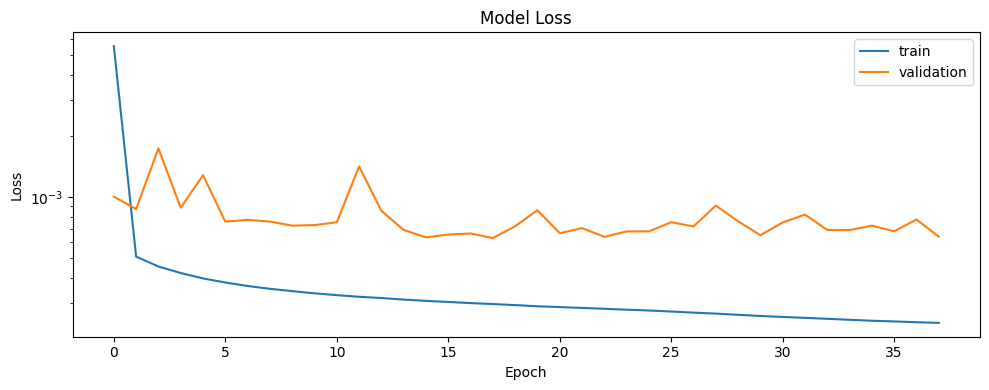

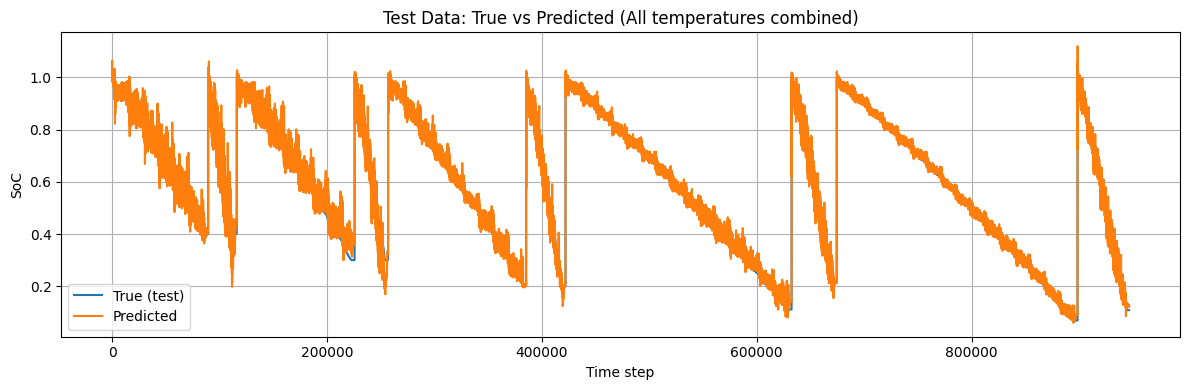


=== Architecture 2 Results ===
                   model_name      rmse       mae  batch            dim conv
0  Panasonic_CNN1_BiLSTM3_att  0.025077  0.015935    256  [110, 90, 70]   32


In [12]:
# Cell 13: Train Architecture 2 (1xCNN + 3xBiLSTM + Attention) - Grid Search
latent_dimension = [[110, 90, 70]]
conv_dimension = [32]
loss_function = ['mse']
learning_rates = [5e-5]
batch_sizes = [256]

results_arch2 = []
run_id = 0

for conv in conv_dimension:
    for lr in learning_rates:
        for dim in latent_dimension:
            for loss in loss_function:
                for batch in batch_sizes:
                    run_id += 1
                    print(f'\n=== Run {run_id} | conv={conv} dim={dim} lr={lr} batch={batch} ===')
                    opts = Adam(learning_rate=lr)
                    result = Optimize(
                        model_fn=create_Cnn1_Bilstm3,
                        opts=opts, dim=dim, loss=loss, conv=conv,
                        batch=batch, model_name='Panasonic_CNN1_BiLSTM3_att'
                    )
                    results_arch2.append(result)

if results_arch2:
    df_results = pd.DataFrame(results_arch2).sort_values('rmse')
    print('\n=== Architecture 2 Results ===')
    print(df_results[['model_name', 'rmse', 'mae', 'batch', 'dim', 'conv']].to_string())


===== Per-file results for CNN1_BiLSTM3_att =====
25degC/UDDS                    | RMSE=0.009828 | MAE=0.007927
10degC/UDDS                    | RMSE=0.016001 | MAE=0.012397
25degC/US06                    | RMSE=0.016498 | MAE=0.012548
0degC/UDDS                     | RMSE=0.016691 | MAE=0.011456
-20degC/UDDS                   | RMSE=0.021512 | MAE=0.016051
10degC/US06                    | RMSE=0.024537 | MAE=0.018956
0degC/US06                     | RMSE=0.027779 | MAE=0.021110
-10degC/UDDS                   | RMSE=0.032926 | MAE=0.023515
-10degC/US06                   | RMSE=0.062824 | MAE=0.046685
-20degC/US06                   | RMSE=0.069369 | MAE=0.057793

[Top-2 Best Test Files by RMSE]
25degC/UDDS | RMSE=0.009828 | MAE=0.007927
10degC/UDDS | RMSE=0.016001 | MAE=0.012397


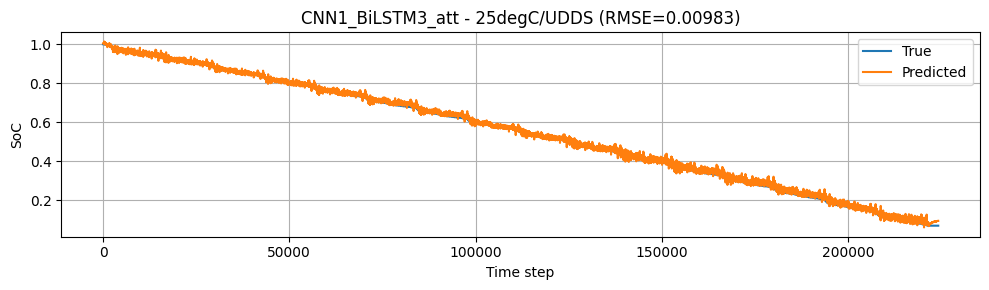

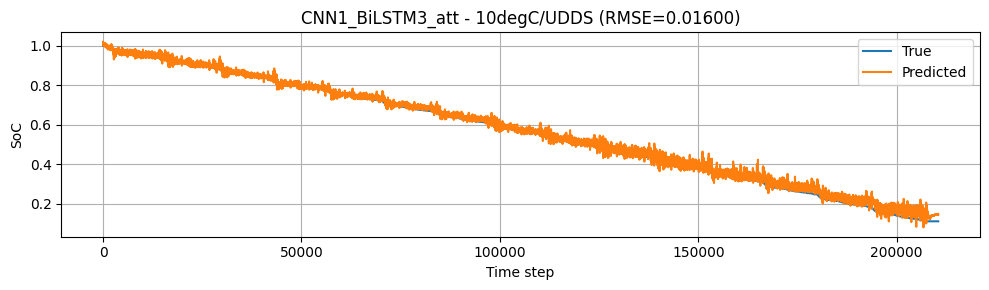

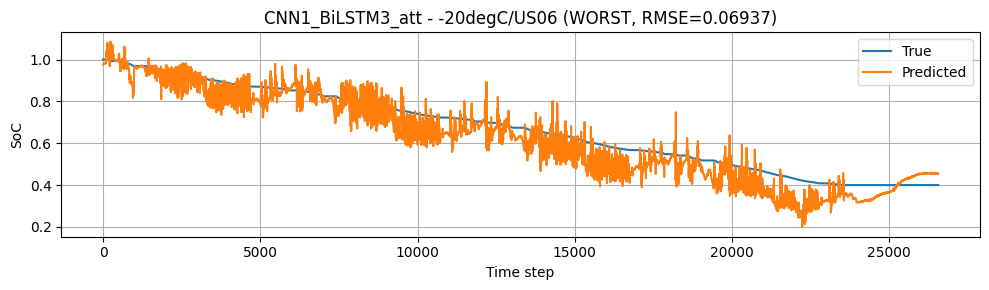

In [13]:
# Cell 14: Per-file evaluation for Architecture 2
model_arch2 = load_model(
    os.path.join(SAVE_DIR, 'model_Panasonic_CNN1_BiLSTM3_att.keras'),
    custom_objects={'SeqSelfAttention': SeqSelfAttention}
)
results_pf_arch2 = evaluate_per_file(model_arch2, 'CNN1_BiLSTM3_att')

---
## Training: Architecture 3 - 2xCNN + 3xBiLSTM + Attention

In [ ]:
# Cell 15: Train Architecture 3 (2xCNN + 3xBiLSTM + Attention) - Grid Search
results_arch3 = []
result = Optimize(
    model_fn=create_Cnn2_Bilstm3,
    opts=Adam(learning_rate=1e-4),
    dim=[70, 50, 30],
    loss='mse',
    conv=[8, 8],
    batch=256,
    model_name='Panasonic_CNN2_BiLSTM3_att'
)
results_arch3.append(result)

In [ ]:
# Cell 16: Per-file evaluation for Architecture 3
model_arch3 = load_model(
    os.path.join(SAVE_DIR, 'model_Panasonic_CNN2_BiLSTM3_att.keras'),
    custom_objects={'SeqSelfAttention': SeqSelfAttention}
)
results_pf_arch3 = evaluate_per_file(model_arch3, 'CNN2_BiLSTM3_att')

---
## Training: Architecture 4 - 1xCNN + 2xBiLSTM + Attention

In [ ]:
# Cell 17: Train Architecture 4 (1xCNN + 2xBiLSTM + Attention) - Grid Search
results_arch4 = []
result = Optimize(
    model_fn=create_Cnn1_Bilstm2,
    opts=Adam(learning_rate=1e-4),
    dim=[40, 20],
    loss='mse',
    conv=8,
    batch=256,
    model_name='Panasonic_CNN1_BiLSTM2_att'
)
results_arch4.append(result)

In [ ]:
# Cell 18: Per-file evaluation for Architecture 4
model_arch4 = load_model(
    os.path.join(SAVE_DIR, 'model_Panasonic_CNN1_BiLSTM2_att.keras'),
    custom_objects={'SeqSelfAttention': SeqSelfAttention}
)
results_pf_arch4 = evaluate_per_file(model_arch4, 'CNN1_BiLSTM2_att')

---
## Summary: Compare all architectures

In [ ]:
# Cell 19: Compare all architectures
all_results = results_arch1 + results_arch2 + results_arch3 + results_arch4
df_all = pd.DataFrame(all_results).sort_values('rmse')
print('=== All Architectures Ranked by RMSE ===')
print(df_all[['model_name', 'rmse', 'mae', 'batch', 'dim', 'conv', 'time_min']].to_string(index=False))
print(f'\nBest model: {df_all.iloc[0]["model_name"]} with RMSE={df_all.iloc[0]["rmse"]:.6f}')